In [1]:
import sys

sys.path.append("../..")

In [2]:
import numpy as np 
import pandas as pd

from tqdm import tqdm 

from matplotlib import pyplot as plt 

from xaikd import models, datasets
from xaikd.utils import metrics

In [3]:
MODEL_NAME = "cifar100-vgg11-p1"
model = models.get_model(MODEL_NAME)

In [4]:
coarse_label_names = pd.read_csv("../../xaikd/resources/cifar100-label-mapping.csv")["coarse_label_name"].unique().tolist()

coarse_label_names = sorted(coarse_label_names)

coarse_label_names

['aquatic_mammals',
 'fish',
 'flowers',
 'food_containers',
 'fruit_and_vegetables',
 'household_electrical_devices',
 'household_furniture',
 'insects',
 'large_carnivores',
 'large_man_made_outdoor_things',
 'large_natural_outdoor_scenes',
 'large_omnivores_and_herbivores',
 'medium_mammals',
 'non_insect_invertebrates',
 'people',
 'reptiles',
 'small_mammals',
 'trees',
 'vehicles_1',
 'vehicles_2']

In [5]:
def ano():
    ds = datasets.construct("cifar100")
    
    dl = ds.loader(train_split=False)
    
    acc = metrics.accuracy(
        model, 
        dl, 
        device="cpu",
        num_classes=100
    
    )
    return acc
# ano()

import torch
import torchmetrics
@torch.no_grad()
def compute_acc(model):
#     model = model.to("cuda")
    ds = datasets.construct("cifar100")
    
    dl = ds.loader(train_split=False)
      
    acc = torchmetrics.Accuracy(task="multiclass", num_classes=model.num_classes)
    
    for batch in tqdm(dl):

        x, y = batch 

        logits = model(x).cpu()

        acc.update(logits, y)
    
    acc = acc.compute()

    print(f"Validation accuracy: {acc}")
compute_acc(model)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [00:52<00:00,  3.01it/s]

Validation accuracy: 0.5842000246047974


In [6]:
@torch.no_grad()
def ano():
    
    arr_rows = []
    for lix, label in tqdm(enumerate(coarse_label_names)):
        ds = datasets.construct(f"cifar100-{label}")
        row = dict(label=label)
        
        for name, train_split in zip(["train", "val"], [True, False]):
            dl = ds.loader(train_split=train_split)
            acc = metrics.accuracy_with_subclasses(
                model, 
                dl, 
                ds.selected_classes,
                ds.transform_target,
                device="cpu"
            )
            row[f"{name}_acc"] = acc
            
        arr_rows.append(row)

            
    return pd.DataFrame(arr_rows)
            
df = ano()

0it [00:00, ?it/s]

We are building `cifar100-aquatic_mammals` containing 5 fine classes
> beaver (4)
> dolphin (30)
> otter (55)
> seal (72)
> whale (95)


1it [00:12, 12.98s/it]

We are building `cifar100-fish` containing 5 fine classes
> aquarium_fish (1)
> flatfish (32)
> ray (67)
> shark (73)
> trout (91)


2it [00:27, 14.17s/it]

...

18it [03:56, 12.86s/it]

We are building `cifar100-vehicles_1` containing 5 fine classes
> bicycle (8)
> bus (13)
> motorcycle (48)
> pickup_truck (58)
> train (90)


19it [04:09, 13.04s/it]

We are building `cifar100-vehicles_2` containing 5 fine classes
> lawn_mower (41)
> rocket (69)
> streetcar (81)
> tank (85)
> tractor (89)


20it [04:23, 13.19s/it]


In [7]:
df

,label,train_acc,val_acc
0,aquatic_mammals,0.9032,0.632
1,fish,0.9388,0.752
2,flowers,0.9344,0.740
3,food_containers,0.9492,0.782
4,fruit_and_vegetables,0.9620,0.842
5,household_electrical_devices,0.9660,0.782
6,household_furniture,0.9644,0.756
7,insects,0.9532,0.772
8,large_carnivores,0.9604,0.826
9,large_man_made_outdoor_things,0.9716,0.858


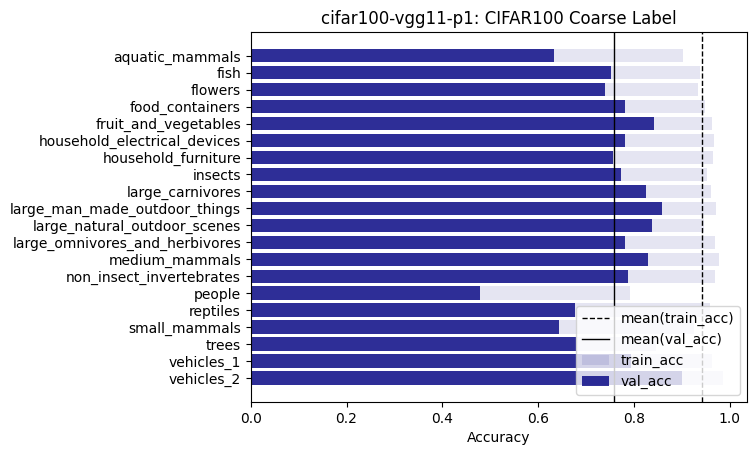

In [8]:
def viz():
    
    ticks = np.arange(df.shape[0])[::-1]
    plt.title(f"{MODEL_NAME}: CIFAR100 Coarse Label")
    for cix, col in enumerate(["train_acc", "val_acc"]):
        plt.barh(ticks, df[col], label=col, color="navy", alpha=0.1 if cix == 0 else 0.8)
    
        plt.axvline(df[col].mean(), label=f"mean({col})", ls="-" if cix == 1 else "--", lw=1, color="k")
    plt.yticks(ticks, df.label.values)
    plt.legend()
    plt.xlabel("Accuracy")
viz()

In [9]:
print("\n".join(
    map(
        lambda x: f"cifar100-{x}",
        coarse_label_names
    )
))

cifar100-aquatic_mammals
cifar100-fish
cifar100-flowers
cifar100-food_containers
cifar100-fruit_and_vegetables
cifar100-household_electrical_devices
cifar100-household_furniture
cifar100-insects
cifar100-large_carnivores
cifar100-large_man_made_outdoor_things
cifar100-large_natural_outdoor_scenes
cifar100-large_omnivores_and_herbivores
cifar100-medium_mammals
cifar100-non_insect_invertebrates
cifar100-people
cifar100-reptiles
cifar100-small_mammals
cifar100-trees
cifar100-vehicles_1
cifar100-vehicles_2
